In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("../data/telco_churn.csv")
df["Churn"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
df.dropna(inplace=True)
df.drop("customerID", axis=1, inplace=True)
df["Churn"].unique()

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

In [ ]:
df.head()

How many customers left?

In [79]:
#how many customers left?
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

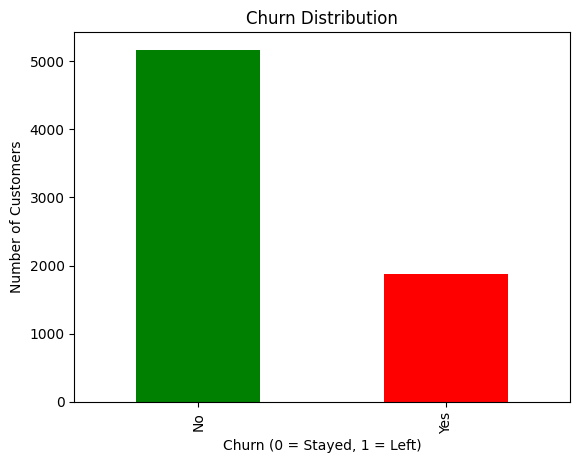

In [103]:

df["Churn"].value_counts().plot(kind="bar", color=['green','red'])
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()

In [81]:
#does the contract type affect churn?
pd.crosstab(df["Contract"], df["Churn"])
pd.crosstab(df["Contract"], df["Churn"], normalize='index')*100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


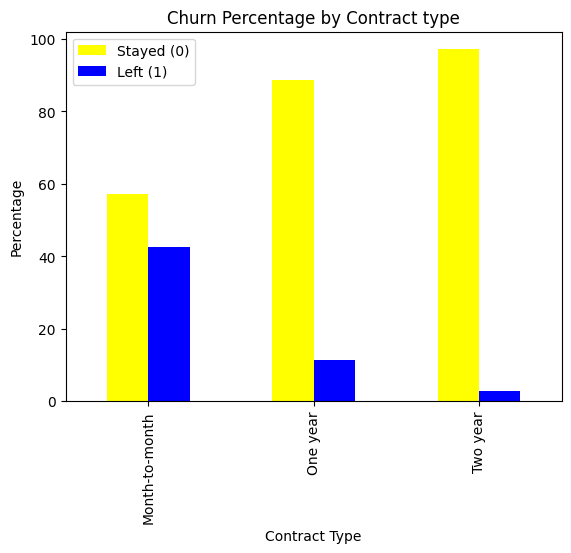

In [105]:
contract_churn=pd.crosstab(df["Contract"], df["Churn"], normalize='index')*100
contract_churn.plot(kind="bar", color=['yellow','blue'])
plt.title("Churn Percentage by Contract type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(["Stayed (0)", "Left (1)"])
plt.show()

In [83]:
#does the tenure affect churn?
df.groupby("Churn")["tenure"].mean()

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

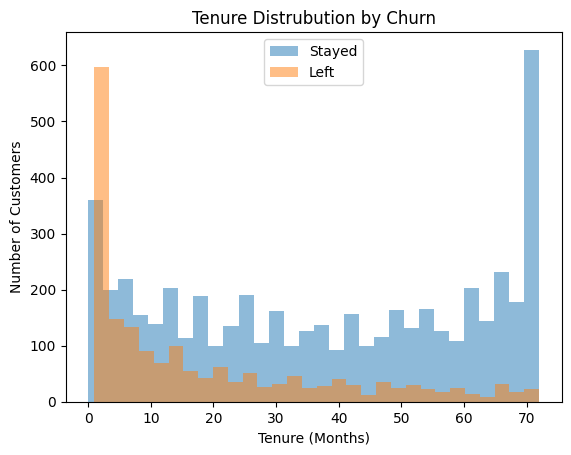

In [87]:
plt.hist(df[df["Churn"]==0]['tenure'], bins=30, alpha=0.5, label='Stayed')
plt.hist(df[df["Churn"]==1]['tenure'], bins=30, alpha=0.5, label='Left')
plt.title("Tenure Distrubution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

In [91]:
#do higher monthly charges increase churn?
df.groupby("Churn")["MonthlyCharges"].mean()


Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

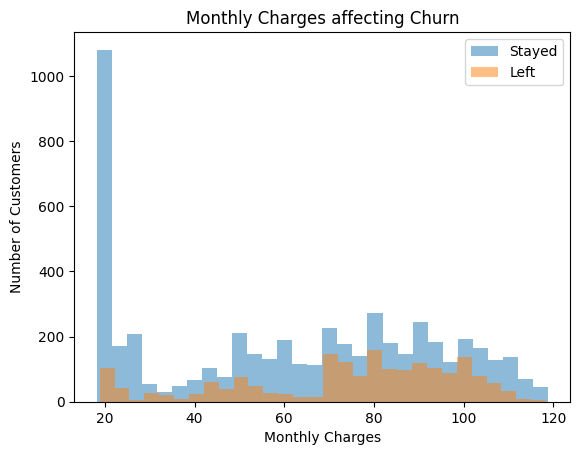

In [92]:
plt.hist(df[df["Churn"]==0]['MonthlyCharges'], bins=30, alpha=0.5, label='Stayed')
plt.hist(df[df["Churn"]==1]['MonthlyCharges'], bins=30, alpha=0.5, label='Left')
plt.title("Monthly Charges affecting Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

In [93]:
df["ChargeGroup"] = pd.cut(df["MonthlyCharges"], bins=5)

pd.crosstab(df["ChargeGroup"], df["Churn"], normalize="index") * 100

Churn,0,1
ChargeGroup,,
"(18.15, 38.35]",88.592098,11.407902
"(38.35, 58.45]",73.034826,26.965174
"(58.45, 78.55]",70.519386,29.480614
"(78.55, 98.65]",63.033954,36.966046
"(98.65, 118.75]",69.942748,30.057252


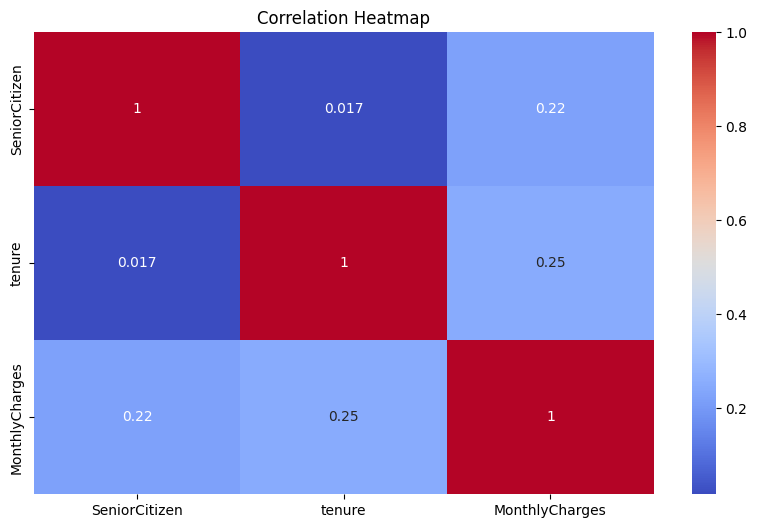

In [106]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [94]:
#PREDICTION MODEL
df_encoded=pd.get_dummies(df, drop_first=True)
X=df_encoded.drop("Churn",axis=1)
y=df_encoded["Churn"]

model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [96]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8190205819730305
Confusion:
 [[933 103]
 [152 221]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



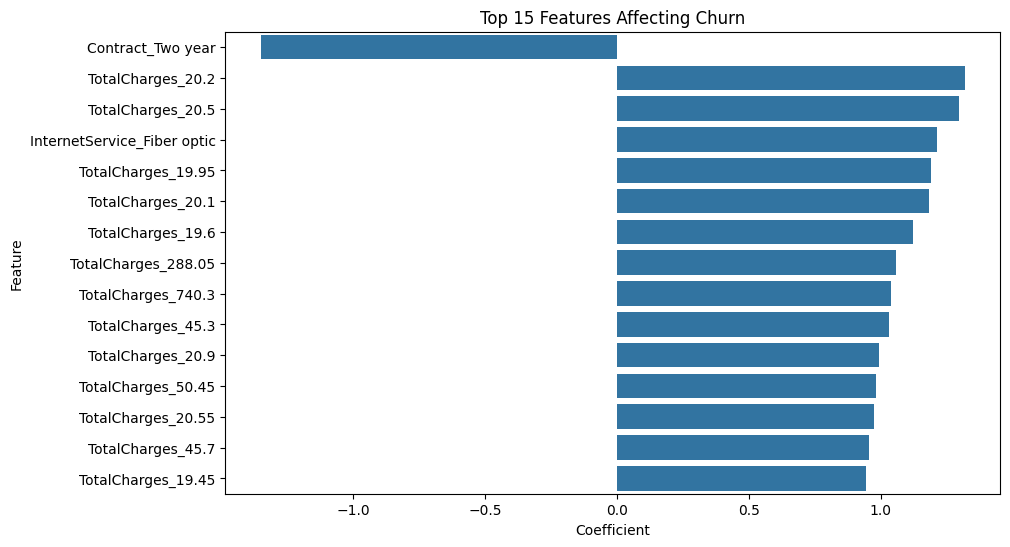

In [98]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='AbsCoef', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(15))
plt.title("Top 15 Features Affecting Churn")
plt.show()

In [109]:
# Revenue at Risk: Sum of MonthlyCharges for people predicted to churn
revenue_at_risk = results[results['Predicted_Churn'] == 1]['MonthlyCharges'].sum()

print(f"--- BUSINESS IMPACT ---")
print(f"Total Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")
print(f"Potential Revenue Saved (if 20% retention): ${revenue_at_risk * 0.20:,.2f}")

--- BUSINESS IMPACT ---
Total Monthly Revenue at Risk: $45,451.50
Potential Revenue Saved (if 20% retention): $9,090.30
-------------------------
